

report = """
╔══════════════════════════════════════════════════════╗
║     GLOBAL DATA JOB MARKET — INTELLIGENCE REPORT    ║
║              Analyst: Vikas M Vicky                  ║
║                   April 2026                         ║
╚══════════════════════════════════════════════════════╝

📦 DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━
- Source         : LinkedIn Job Postings (Kaggle)
- Total records  : 1,23,849 jobs
- Data roles     : 8,819 jobs analyzed
- Time period    : April 2024 snapshot
- Salary data    : Available for ~5,000 roles

📊 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━

1. MOST IN-DEMAND ROLES
   🥇 Business Analyst    — 146 postings
   🥈 Data Analyst        — 137 postings
   🥉 Financial Analyst   — 113 postings
   4th Data Engineer      —  90 postings
   5th Data Scientist     —  56 postings

2. SALARY BY EXPERIENCE
   Internship     →  $56,160  (starting point)
   Entry Level    →  $84,318  (+50% jump!)
   Associate      →  $82,330
   Mid-Senior     → $114,550  (2x entry level)
   Director       → $212,000
   Executive      → $215,000

3. WORK TYPE BREAKDOWN
   Full-time   → 77%  (dominates market)
   Contract    → 20%  (growing trend)
   Part-time   →  1.3%
   Internship  →  0.9%

4. REMOTE VS OFFICE
   Only 14.4% of data jobs allow remote work
   Office presence still dominates in 2026

💡 TOP 3 BUSINESS INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Business Analyst > Data Scientist in demand
   → Companies value business thinking over
     pure technical skills

2. Biggest salary jump = Internship → Entry Level
   → First full-time job is most critical
     career decision

3. Remote data jobs are rare (14.4%)
   → Freshers should be open to relocation
     for better opportunities

⚠️  DATA LIMITATIONS
━━━━━━━━━━━━━━━━━━━━
- Single month snapshot (April 2024 only)
- 60% of roles have no salary listed
- US market data — India trends may differ
- Company size not available in dataset

🔮 WHAT'S NEXT
━━━━━━━━━━━━━━━━━━━━
Week 2: Build ML model to predict salary bracket
        based on job title + location + skills
        Deploy as interactive Streamlit dashboard
"""

print(report)

# Save report
with open('../data/day5_insights_report.txt', 'w') as f:
    f.write(report)
    
print("\n✅ Report saved!")

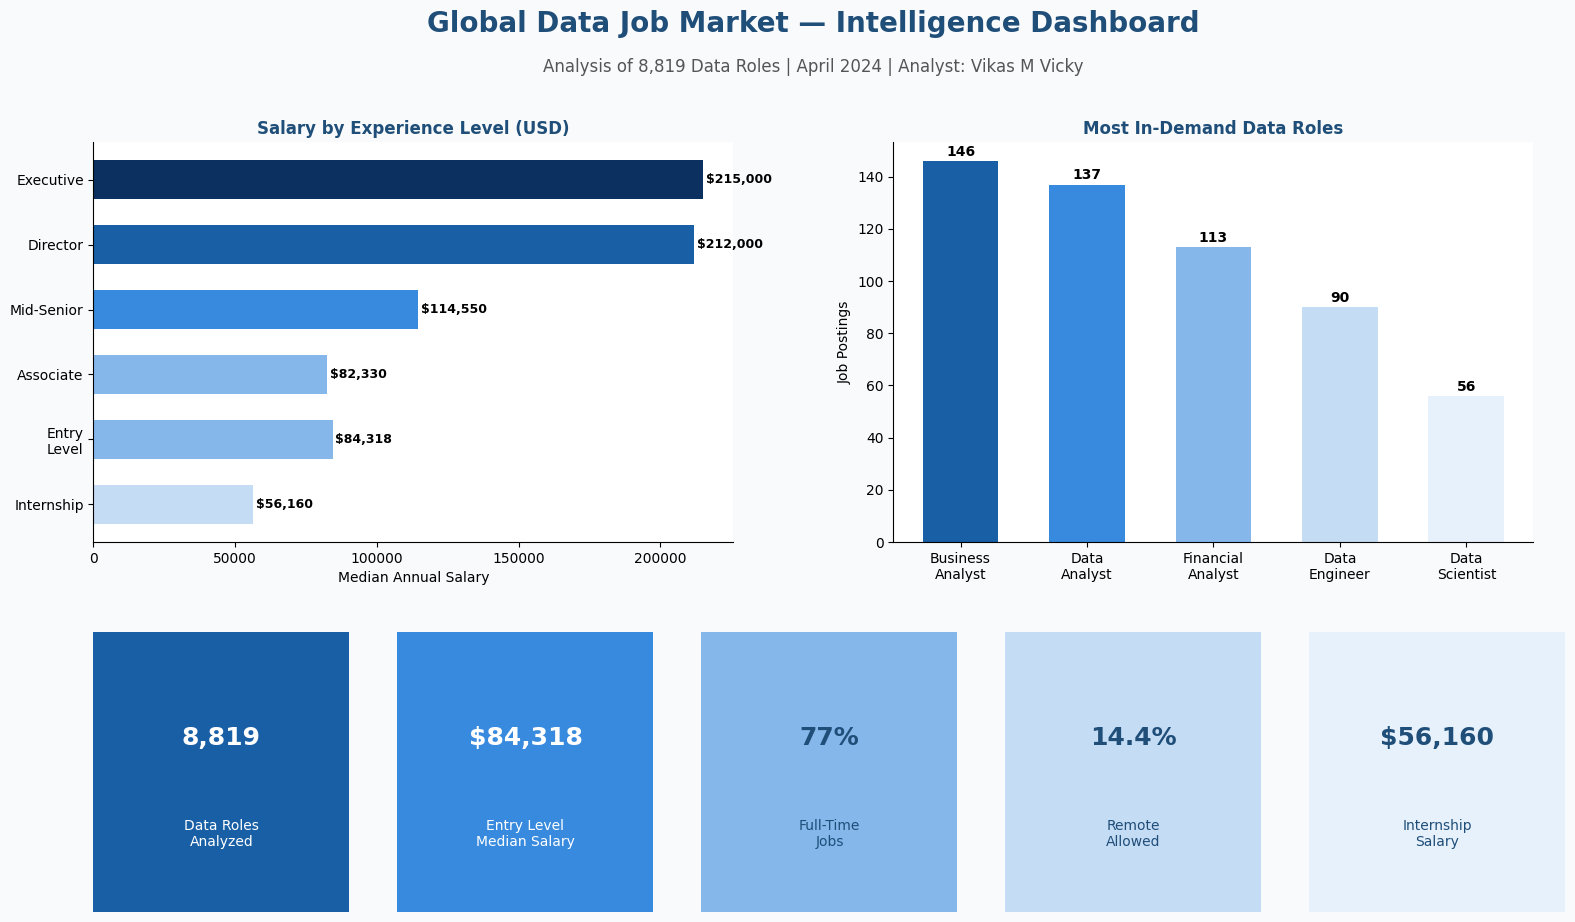

✅ Summary dashboard saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8FAFC')

# Title
fig.text(0.5, 0.96,
         'Global Data Job Market — Intelligence Dashboard',
         ha='center', fontsize=20,
         fontweight='bold', color='#1F4E79')
fig.text(0.5, 0.92,
         'Analysis of 8,819 Data Roles | April 2024 | Analyst: Vikas M Vicky',
         ha='center', fontsize=12, color='#555555')

# ── Chart 1 — Salary ladder (left) ──
ax1 = fig.add_axes([0.05, 0.45, 0.40, 0.40])
exp_levels = ['Internship', 'Entry\nLevel',
              'Associate', 'Mid-Senior', 'Director', 'Executive']
salaries = [56160, 84318, 82330, 114550, 212000, 215000]
colors = ['#C5DCF5','#85B7EB','#85B7EB',
          '#378ADD','#185FA5','#0C3060']

bars = ax1.barh(exp_levels, salaries, color=colors, height=0.6)
ax1.set_title('Salary by Experience Level (USD)',
              fontweight='bold', fontsize=12, color='#1F4E79')
ax1.set_xlabel('Median Annual Salary', fontsize=10)

for bar, val in zip(bars, salaries):
    ax1.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9,
             fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2 — Top titles (right) ──
ax2 = fig.add_axes([0.55, 0.45, 0.40, 0.40])
titles = ['Business\nAnalyst', 'Data\nAnalyst',
          'Financial\nAnalyst', 'Data\nEngineer',
          'Data\nScientist']
counts = [146, 137, 113, 90, 56]
colors2 = ['#185FA5','#378ADD','#85B7EB','#C5DCF5','#E6F1FB']

bars2 = ax2.bar(titles, counts, color=colors2, width=0.6)
ax2.set_title('Most In-Demand Data Roles',
              fontweight='bold', fontsize=12, color='#1F4E79')
ax2.set_ylabel('Job Postings', fontsize=10)

for bar, val in zip(bars2, counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(val), ha='center',
             fontsize=10, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── KPI Cards (bottom) ──
kpis = [
    ('8,819', 'Data Roles\nAnalyzed', '#185FA5'),
    ('$84,318', 'Entry Level\nMedian Salary', '#378ADD'),
    ('77%', 'Full-Time\nJobs', '#85B7EB'),
    ('14.4%', 'Remote\nAllowed', '#C5DCF5'),
    ('$56,160', 'Internship\nSalary', '#E6F1FB'),
]

for i, (val, label, color) in enumerate(kpis):
    ax = fig.add_axes([0.05 + i*0.19, 0.08, 0.16, 0.28])
    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    text_color = 'white' if i < 2 else '#1F4E79'
    ax.text(0.5, 0.62, val, ha='center', va='center',
            fontsize=18, fontweight='bold',
            color=text_color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=10, color=text_color,
            transform=ax.transAxes)

# Create data folder if not exists
os.makedirs('../../data', exist_ok=True)

# Save dashboard
plt.savefig('../../data/day5_summary_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')

plt.show()

print("✅ Summary dashboard saved!")